# 📚 Book Recommendation System

## A Hybrid Approach: Content-Based + Collaborative Filtering

---

Building an effective book recommendation system is one of the classic yet challenging problems in machine learning. In this notebook, we implement a **production-grade hybrid recommendation system** on the **Book-Crossing dataset**, combining:

| Approach | Model | Handles |
|---|---|---|
| Content-Based Filtering | TF-IDF + Cosine Similarity | Cold-start for new users |
| Collaborative Filtering (Explicit) | SVD++ (scikit-surprise) | Explicit ratings (1–10) |
| Collaborative Filtering (Implicit) | ALS (implicit library) | Implicit interactions (rating=0) |
| **Hybrid Ensemble** | Weighted Score Fusion | Best of all worlds |

**Dataset**: [Book-Crossing Dataset](http://www2.informatik.uni-freiburg.de/~cziegler/BX/)  
**Size**: ~278K users · ~271K books · ~1.15M ratings

---

## Pipeline Overview

```
Raw Data ──► Data Loading & Inspection
         ──► Exploratory Data Analysis
         ──► Data Preprocessing & Cleaning
         ──► Content-Based Model (TF-IDF)
         ──► Collaborative Filtering — SVD++ (Explicit)
         ──► Collaborative Filtering — ALS (Implicit)
         ──► Hybrid Ensemble
         ──► Evaluation
         ──► Inference & Demo
```

## 1. Import Libraries

We leverage a carefully selected stack:

- **`pandas` / `numpy`** — data wrangling and numerical computation
- **`scikit-learn`** — TF-IDF vectorization, cosine similarity, train/test splitting, metrics
- **`scikit-surprise`** — matrix factorization algorithms optimized for explicit rating data (SVD++)
- **`implicit`** — high-performance ALS for implicit feedback using Cython/C++ under the hood
- **`scipy`** — sparse matrix utilities required by `implicit`
- **`matplotlib` / `seaborn`** — visualizations
- **`warnings`** — suppress non-critical deprecation noise

In [61]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error

from surprise import SVDpp, Dataset, Reader
from surprise.model_selection import cross_validate, train_test_split as surprise_split
from surprise import accuracy as surprise_accuracy

import implicit

import os
import time

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#e6edf3',
    'grid.color': '#21262d',
    'figure.dpi': 120,
})

PALETTE = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657', '#79c0ff']

print('All libraries imported successfully.')
print(f'implicit version: {implicit.__version__}')

All libraries imported successfully.
implicit version: 0.7.3


## 2. Load Dataset

The Book-Crossing dataset consists of three files:

| File | Description |
|---|---|
| `Books.csv` | Book metadata (title, author, year, publisher, cover image URLs) |
| `Users.csv` | User demographics (location, age) |
| `Ratings.csv` | User–book ratings on a scale 0–10 (0 = implicit/no rating) |

We use `on_bad_lines='skip'` to gracefully handle any malformed rows in the CSV files.

In [62]:
DATA_DIR = '../Dataset/'

books   = pd.read_csv(os.path.join(DATA_DIR, 'Books.csv'),   on_bad_lines='skip', low_memory=False)
users   = pd.read_csv(os.path.join(DATA_DIR, 'Users.csv'),   on_bad_lines='skip', low_memory=False)
ratings = pd.read_csv(os.path.join(DATA_DIR, 'Ratings.csv'), on_bad_lines='skip', low_memory=False)

print(f'Books   shape : {books.shape}')
print(f'Users   shape : {users.shape}')
print(f'Ratings shape : {ratings.shape}')

Books   shape : (271360, 8)
Users   shape : (278858, 3)
Ratings shape : (1149780, 3)


In [63]:
books.head(3)

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...


In [64]:
users.head(3)

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN


In [65]:
ratings.head(3)

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0


## 3. Exploratory Data Analysis (EDA)

Before building any model, we need to understand the data distribution, sparsity level, and quality of each table. Key questions:

- **How are ratings distributed?** Are they mostly implicit (0) or explicit (1–10)?
- **How active are users and books?** Do we have a long-tail distribution?
- **What is the sparsity of the user–item matrix?** This directly impacts which algorithm works best.
- **Are there missing values or anomalies?**

In [66]:
print('=== BOOKS ===')
print(books.info())
print('\nMissing values:')
print(books.isnull().sum())

=== BOOKS ===
<class 'pandas.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   ISBN                 271360 non-null  str  
 1   Book-Title           271360 non-null  str  
 2   Book-Author          271358 non-null  str  
 3   Year-Of-Publication  271360 non-null  str  
 4   Publisher            271358 non-null  str  
 5   Image-URL-S          271360 non-null  str  
 6   Image-URL-M          271360 non-null  str  
 7   Image-URL-L          271357 non-null  str  
dtypes: str(8)
memory usage: 84.4 MB
None

Missing values:
ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64


In [67]:
print('=== USERS ===')
print(users.info())
print('\nMissing values:')
print(users.isnull().sum())

=== USERS ===
<class 'pandas.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  str    
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 13.4 MB
None

Missing values:
User-ID          0
Location         0
Age         110762
dtype: int64


In [68]:
print('=== RATINGS ===')
print(ratings.info())
print('\nMissing values:')
print(ratings.isnull().sum())

=== RATINGS ===
<class 'pandas.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype
---  ------       --------------    -----
 0   User-ID      1149780 non-null  int64
 1   ISBN         1149780 non-null  str  
 2   Book-Rating  1149780 non-null  int64
dtypes: int64(2), str(1)
memory usage: 37.3 MB
None

Missing values:
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


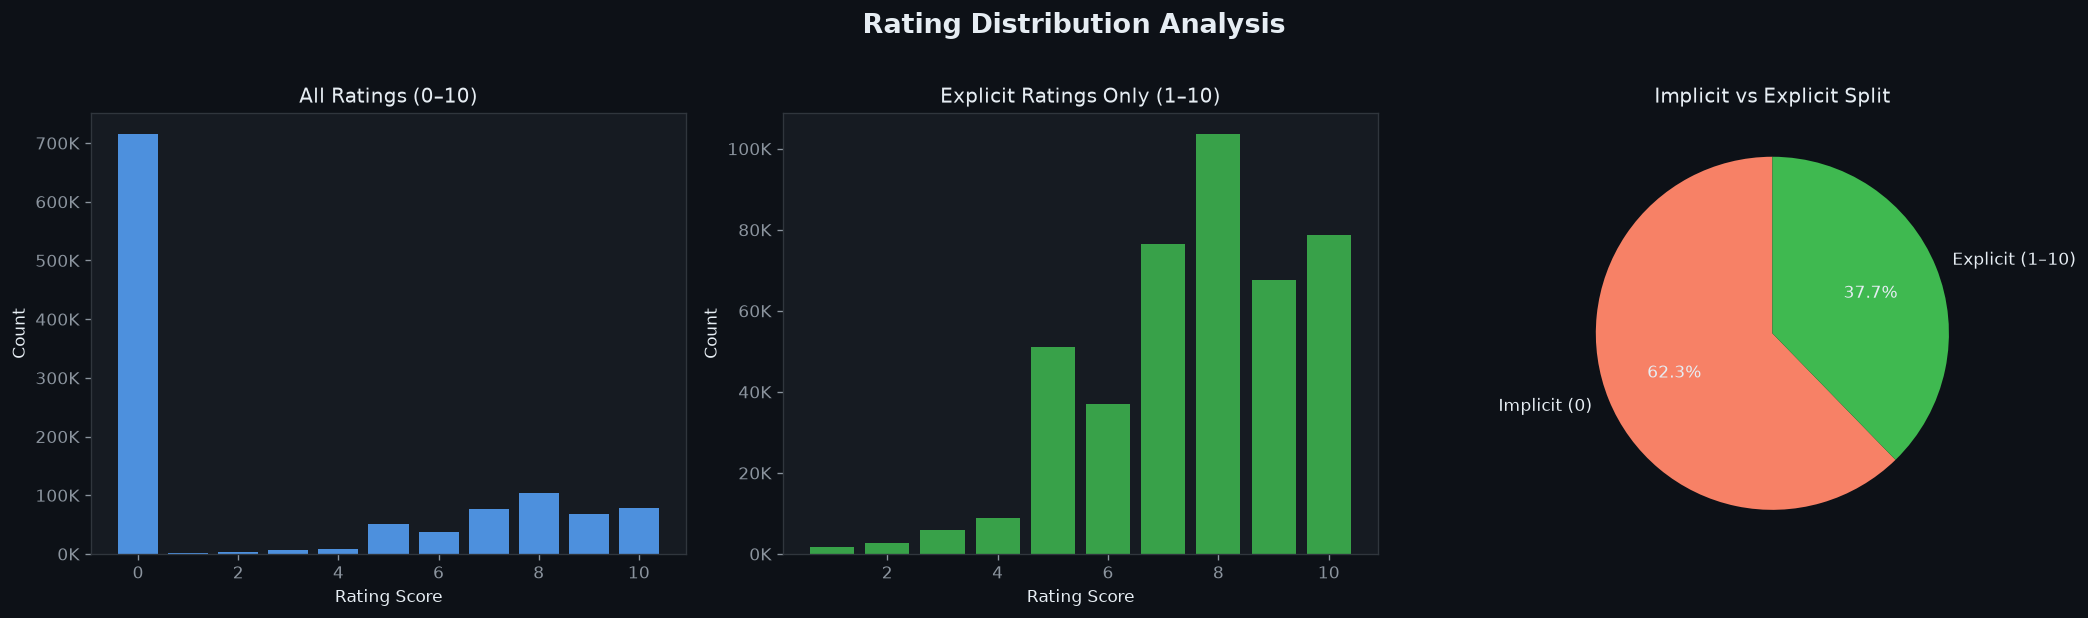

Total ratings  : 1,149,780
Implicit (0)   : 716,109 (62.3%)
Explicit (1-10): 433,671 (37.7%)


In [69]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Rating Distribution Analysis', fontsize=16, fontweight='bold', color='#e6edf3', y=1.02)

all_counts = ratings['Book-Rating'].value_counts().sort_index()
axes[0].bar(all_counts.index, all_counts.values, color=PALETTE[0], alpha=0.85)
axes[0].set_title('All Ratings (0–10)', color='#e6edf3')
axes[0].set_xlabel('Rating Score')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{int(x/1e3)}K'))

explicit = ratings[ratings['Book-Rating'] > 0]
exp_counts = explicit['Book-Rating'].value_counts().sort_index()
axes[1].bar(exp_counts.index, exp_counts.values, color=PALETTE[1], alpha=0.85)
axes[1].set_title('Explicit Ratings Only (1–10)', color='#e6edf3')
axes[1].set_xlabel('Rating Score')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K'))

implicit_count = (ratings['Book-Rating'] == 0).sum()
explicit_count = (ratings['Book-Rating'] > 0).sum()
axes[2].pie(
    [implicit_count, explicit_count],
    labels=['Implicit (0)', 'Explicit (1–10)'],
    autopct='%1.1f%%',
    colors=[PALETTE[2], PALETTE[1]],
    startangle=90,
    textprops={'color': '#e6edf3'}
)
axes[2].set_title('Implicit vs Explicit Split', color='#e6edf3')

plt.tight_layout()
plt.show()

print(f'Total ratings  : {len(ratings):,}')
print(f'Implicit (0)   : {implicit_count:,} ({implicit_count/len(ratings)*100:.1f}%)')
print(f'Explicit (1-10): {explicit_count:,} ({explicit_count/len(ratings)*100:.1f}%)')

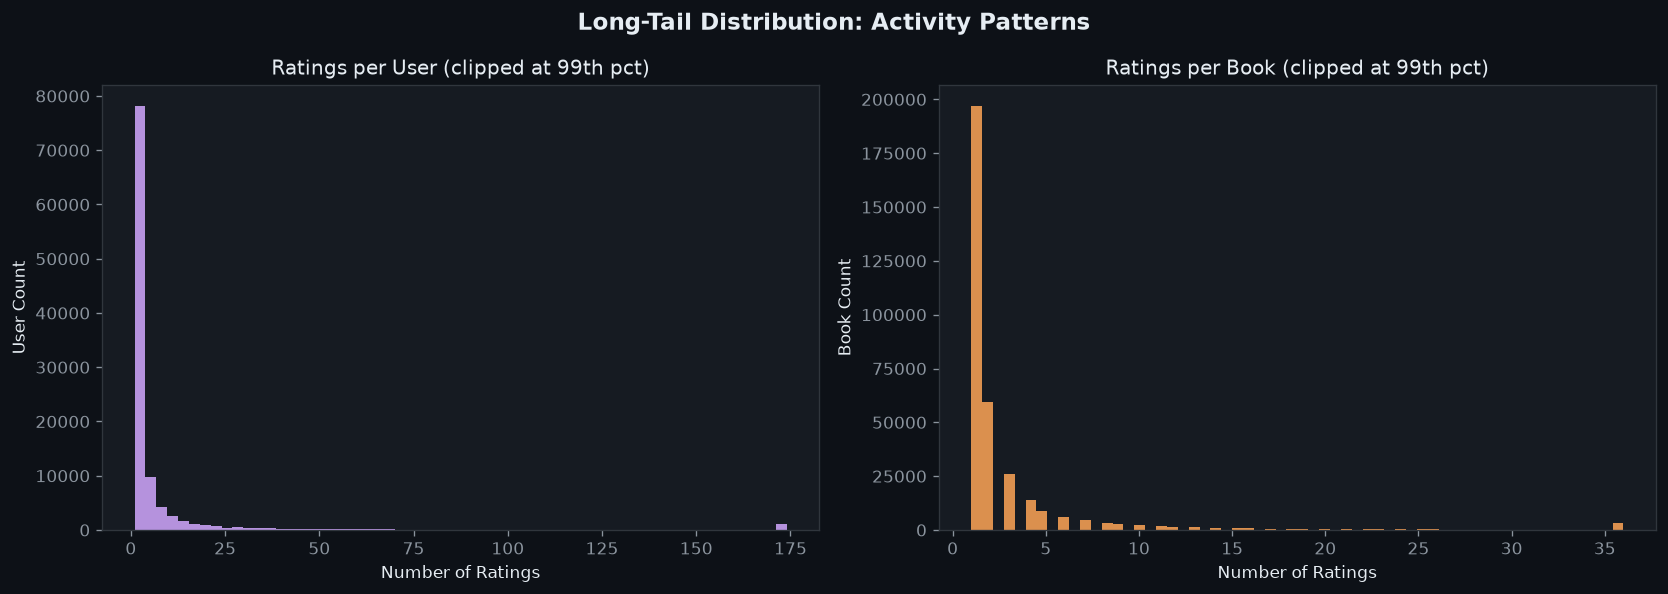

Users with only 1 rating  : 59,166 (56.2%)
Books  with only 1 rating : 197,045 (57.9%)
Max ratings per user       : 13,602
Max ratings per book       : 2,502


In [70]:
user_activity    = ratings.groupby('User-ID').size()
book_popularity  = ratings.groupby('ISBN').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Long-Tail Distribution: Activity Patterns', fontsize=14, fontweight='bold', color='#e6edf3')

axes[0].hist(user_activity.clip(upper=user_activity.quantile(0.99)), bins=60, color=PALETTE[3], alpha=0.85)
axes[0].set_title('Ratings per User (clipped at 99th pct)', color='#e6edf3')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('User Count')

axes[1].hist(book_popularity.clip(upper=book_popularity.quantile(0.99)), bins=60, color=PALETTE[4], alpha=0.85)
axes[1].set_title('Ratings per Book (clipped at 99th pct)', color='#e6edf3')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Book Count')

plt.tight_layout()
plt.show()

print(f'Users with only 1 rating  : {(user_activity == 1).sum():,} ({(user_activity == 1).mean()*100:.1f}%)')
print(f'Books  with only 1 rating : {(book_popularity == 1).sum():,} ({(book_popularity == 1).mean()*100:.1f}%)')
print(f'Max ratings per user       : {user_activity.max():,}')
print(f'Max ratings per book       : {book_popularity.max():,}')

In [71]:
n_users  = ratings['User-ID'].nunique()
n_books  = ratings['ISBN'].nunique()
n_interactions = len(ratings)
sparsity = 1 - (n_interactions / (n_users * n_books))

print(f'Unique users        : {n_users:,}')
print(f'Unique books        : {n_books:,}')
print(f'Total interactions  : {n_interactions:,}')
print(f'Matrix sparsity     : {sparsity:.6%}')

Unique users        : 105,283
Unique books        : 340,556
Total interactions  : 1,149,780
Matrix sparsity     : 99.996793%


## 4. Data Preprocessing

### 4.1 Strategy

The raw dataset has several characteristics that require careful handling:

1. **Extreme sparsity** (>99.99%) — We apply activity-based filtering to retain only users and books with sufficient interactions, producing a denser, more reliable matrix.
2. **Mixed rating semantics** — Rating=0 means the user interacted with the book (implicit feedback), while ratings 1–10 are explicit quality signals. We handle each separately.
3. **Dirty text fields** — Book titles and authors contain mixed case and trailing whitespace that must be normalized before TF-IDF.
4. **Age anomalies** — Some age values are clearly invalid (e.g., 0, >120). We cap them to a sensible range.

### 4.2 Filtering thresholds

We apply a **min-activity filter**: users must have rated at least **10 books**, and books must have received at least **10 ratings**. This is a common practice in RecSys to reduce noise and improve model quality.

In [72]:
books.columns = ['ISBN', 'Title', 'Author', 'Year', 'Publisher', 'Image-S', 'Image-M', 'Image-L']
ratings.columns = ['UserID', 'ISBN', 'Rating']
users.columns   = ['UserID', 'Location', 'Age']

books['Title']  = books['Title'].astype(str).str.strip().str.title()
books['Author'] = books['Author'].astype(str).str.strip().str.title()
books['Year']   = pd.to_numeric(books['Year'], errors='coerce')
books           = books.drop_duplicates(subset='ISBN').reset_index(drop=True)

users['Age'] = pd.to_numeric(users['Age'], errors='coerce')
users['Age'] = users['Age'].where((users['Age'] >= 5) & (users['Age'] <= 100))

print(f'Books after dedup: {len(books):,}')

Books after dedup: 271,360


In [73]:
MIN_USER_RATINGS = 10
MIN_BOOK_RATINGS = 10

def iterative_filter(df, user_col, item_col, min_u, min_i, iterations=3):
    for _ in range(iterations):
        user_counts = df[user_col].value_counts()
        df = df[df[user_col].isin(user_counts[user_counts >= min_u].index)]
        item_counts = df[item_col].value_counts()
        df = df[df[item_col].isin(item_counts[item_counts >= min_i].index)]
    return df.reset_index(drop=True)

ratings_filtered = iterative_filter(ratings, 'UserID', 'ISBN', MIN_USER_RATINGS, MIN_BOOK_RATINGS)

print(f'Original ratings  : {len(ratings):,}')
print(f'Filtered ratings  : {len(ratings_filtered):,}')
print(f'Unique users (filtered): {ratings_filtered["UserID"].nunique():,}')
print(f'Unique books (filtered): {ratings_filtered["ISBN"].nunique():,}')

n2, m2 = ratings_filtered['UserID'].nunique(), ratings_filtered['ISBN'].nunique()
sparsity2 = 1 - len(ratings_filtered) / (n2 * m2)
print(f'New sparsity      : {sparsity2:.4%}')

Original ratings  : 1,149,780
Filtered ratings  : 375,442
Unique users (filtered): 6,827
Unique books (filtered): 13,728
New sparsity      : 99.5994%


In [74]:
explicit_df = ratings_filtered[ratings_filtered['Rating'] > 0].copy()
implicit_df = ratings_filtered.copy()

print(f'Explicit ratings  : {len(explicit_df):,}')
print(f'All interactions  : {len(implicit_df):,}')

books_filtered = books[books['ISBN'].isin(ratings_filtered['ISBN'].unique())].copy()
print(f'Books with ratings: {len(books_filtered):,}')

Explicit ratings  : 121,081
All interactions  : 375,442
Books with ratings: 13,339


## 5. Content-Based Filtering (TF-IDF + Cosine Similarity)

### How it works

Content-based filtering recommends books **similar to a given book** based on their metadata attributes — specifically, the book title, author, and year of publication.

**Pipeline:**
1. Concatenate `Title + Author + Year` into a single `soup` string per book.
2. Apply **TF-IDF** (Term Frequency–Inverse Document Frequency) vectorization to convert each soup into a sparse numerical vector.
3. Compute **pairwise cosine similarity** across all book vectors.
4. For a given book, return the top-N most similar books by cosine score.

**Advantages**: Works even for new users with no rating history (solves the cold-start problem).

**Limitations**: Limited to surface-level metadata; cannot discover serendipitous cross-genre recommendations.

In [75]:
cb_books = books_filtered[['ISBN', 'Title', 'Author', 'Year']].copy()
cb_books['Year'] = cb_books['Year'].fillna(0).astype(int).astype(str).replace('0', '')
cb_books['soup'] = (
    cb_books['Title'].fillna('') + ' ' +
    cb_books['Author'].fillna('') + ' ' +
    cb_books['Author'].fillna('') + ' ' +
    cb_books['Year'].fillna('')
).str.strip()

cb_books = cb_books.reset_index(drop=True)
isbn_to_idx = {isbn: idx for idx, isbn in enumerate(cb_books['ISBN'])}

tfidf = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=2, stop_words='english')
tfidf_matrix = tfidf.fit_transform(cb_books['soup'])

print(f'TF-IDF matrix shape : {tfidf_matrix.shape}')
print(f'Vocabulary size     : {len(tfidf.vocabulary_):,}')

TF-IDF matrix shape : (13339, 19366)
Vocabulary size     : 19,366


In [76]:
def get_content_based_recommendations(isbn, top_n=10):
    if isbn not in isbn_to_idx:
        return pd.DataFrame(columns=['ISBN', 'Title', 'Author', 'Similarity'])
    
    idx = isbn_to_idx[isbn]
    query_vec = tfidf_matrix[idx]
    cos_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_indices = np.argsort(cos_scores)[::-1][1:top_n + 1]
    
    results = cb_books.iloc[top_indices][['ISBN', 'Title', 'Author']].copy()
    results['Similarity'] = cos_scores[top_indices].round(4)
    return results.reset_index(drop=True)

sample_isbn = cb_books['ISBN'].iloc[0]
sample_title = cb_books[cb_books['ISBN'] == sample_isbn]['Title'].values[0]
print(f'Query book: "{sample_title}"')
print()
get_content_based_recommendations(sample_isbn, top_n=10)

Query book: "The Kitchen God'S Wife"



,ISBN,Title,Author,Similarity
0,080410753X,The Kitchen God'S Wife,Amy Tan,0.9519
1,0749399570,The Joy Luck Club,Amy Tan,0.6814
2,067972768X,The Joy Luck Club (Vintage Contemporaries),Amy Tan,0.6706
3,0399150749,The Opposite Of Fate: A Book Of Musings,Amy Tan,0.6586
4,0375701524,The Hundred Secret Senses,Amy Tan,0.6553
5,080411109X,The Hundred Secret Senses,Amy Tan,0.6552
6,0399141146,The Hundred Secret Senses,Amy Tan,0.6550
7,0804114986,The Bonesetter'S Daughter,Amy Tan,0.6503
8,0399146431,The Bonesetter'S Daughter,Amy Tan,0.6499
9,0804106304,The Joy Luck Club,Amy Tan,0.6228


## 6. Collaborative Filtering — Explicit Ratings (SVD++)

### Why SVD++?

**SVD++** is an extension of classic matrix factorization (SVD) that incorporates **implicit feedback** in addition to explicit ratings. It was the key algorithm behind the winning entry of the Netflix Prize competition.

The model learns latent factor vectors for users and items, where predictions are computed as:

$$\hat{r}_{ui} = \mu + b_u + b_i + q_i^T \left( p_u + |N(u)|^{-\frac{1}{2}} \sum_{j \in N(u)} y_j \right)$$

Where:
- $\mu$ = global mean rating
- $b_u, b_i$ = user and item bias terms
- $p_u$ = explicit user latent factors
- $q_i$ = item latent factors
- $y_j$ = implicit feedback factors for items the user has interacted with

**Key hyperparameters:**
- `n_factors=50` — dimensionality of the latent space
- `n_epochs=20` — SGD training epochs
- `lr_all=0.005` — global learning rate
- `reg_all=0.02` — L2 regularization strength

In [77]:
reader = Reader(rating_scale=(1, 10))
surprise_data = Dataset.load_from_df(explicit_df[['UserID', 'ISBN', 'Rating']], reader)

trainset_svd, testset_svd = surprise_split(surprise_data, test_size=0.2, random_state=42)

print(f'SVD++ Trainset size: {trainset_svd.n_ratings:,}')
print(f'SVD++ Testset  size: {len(testset_svd):,}')

SVD++ Trainset size: 96,864
SVD++ Testset  size: 24,217


In [78]:
svdpp = SVDpp(
    n_factors=50,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42,
    verbose=False
)

start = time.time()
svdpp.fit(trainset_svd)
elapsed = time.time() - start

print(f'SVD++ training complete in {elapsed:.1f}s')

SVD++ training complete in 64.2s


In [79]:
predictions_svd = svdpp.test(testset_svd)

rmse_svd = surprise_accuracy.rmse(predictions_svd, verbose=False)
mae_svd  = surprise_accuracy.mae(predictions_svd, verbose=False)

print(f'SVD++ Test RMSE : {rmse_svd:.4f}')
print(f'SVD++ Test MAE  : {mae_svd:.4f}')

SVD++ Test RMSE : 1.5664
SVD++ Test MAE  : 1.2024


In [80]:
full_trainset = surprise_data.build_full_trainset()
svdpp.fit(full_trainset)
print('SVD++ retrained on full explicit dataset.')

SVD++ retrained on full explicit dataset.


### Prediction Error Analysis

Visualizing the error distribution helps diagnose systematic biases in the model — e.g., does it consistently over- or under-predict high/low ratings?

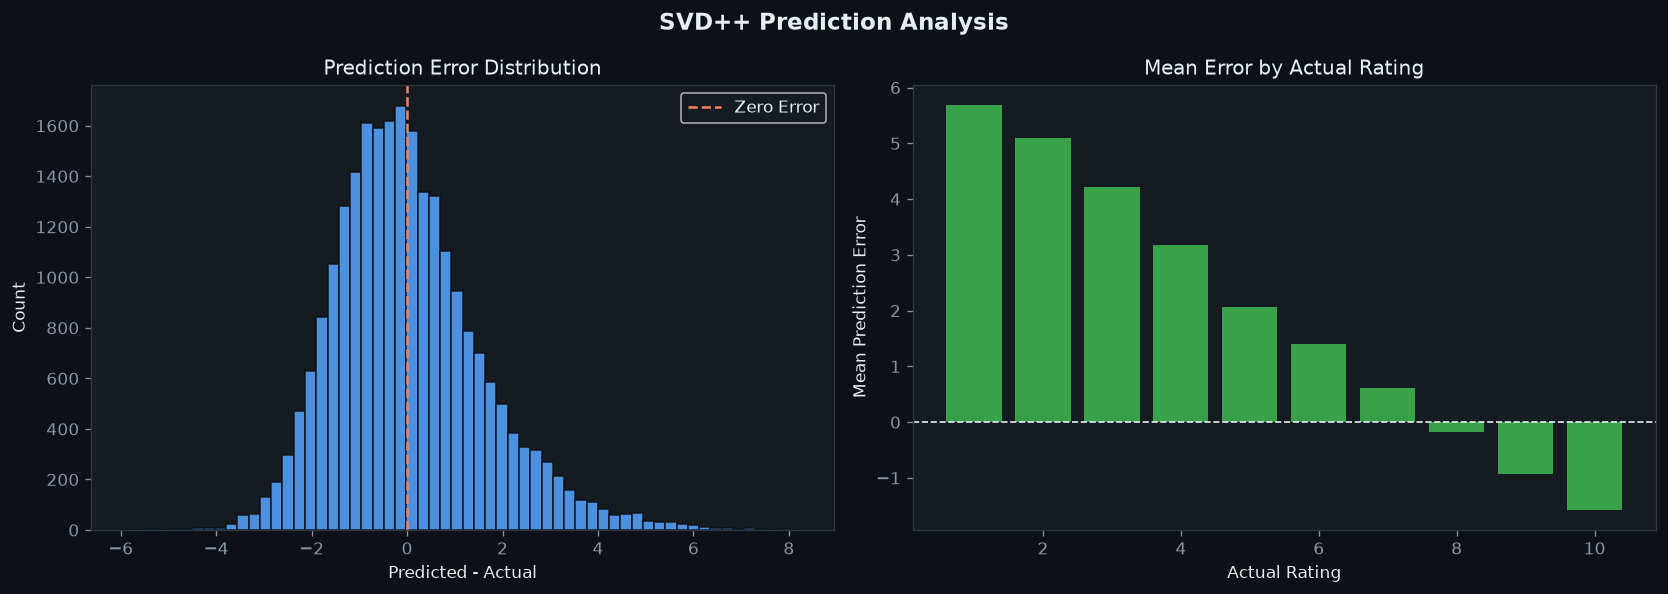

In [81]:
preds_df = pd.DataFrame([
    {'actual': p.r_ui, 'predicted': p.est}
    for p in predictions_svd
])
preds_df['error'] = preds_df['predicted'] - preds_df['actual']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SVD++ Prediction Analysis', fontsize=14, fontweight='bold', color='#e6edf3')

axes[0].hist(preds_df['error'], bins=60, color=PALETTE[0], alpha=0.85, edgecolor='#0d1117')
axes[0].axvline(0, color=PALETTE[2], linestyle='--', linewidth=1.5, label='Zero Error')
axes[0].set_title('Prediction Error Distribution', color='#e6edf3')
axes[0].set_xlabel('Predicted - Actual')
axes[0].set_ylabel('Count')
axes[0].legend()

avg_err_by_actual = preds_df.groupby('actual')['error'].mean()
axes[1].bar(avg_err_by_actual.index, avg_err_by_actual.values, color=PALETTE[1], alpha=0.85)
axes[1].axhline(0, color='#e6edf3', linestyle='--', linewidth=1)
axes[1].set_title('Mean Error by Actual Rating', color='#e6edf3')
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Mean Prediction Error')

plt.tight_layout()
plt.show()

## 7. Collaborative Filtering — Implicit Feedback (ALS)

### Why ALS for Implicit Feedback?

**Alternating Least Squares (ALS)** is specifically designed for **implicit feedback datasets** — situations where all interactions (including rating=0, which means "viewed but not rated") carry signal. The `implicit` library implements a highly optimized ALS with the **Hu, Koren & Volinsky (2008)** confidence weighting scheme:

$$c_{ui} = 1 + \alpha \cdot r_{ui}$$

Where $r_{ui}$ is the raw interaction value and $\alpha$ controls confidence scaling. The objective becomes:

$$\min_{X, Y} \sum_{u,i} c_{ui}(p_{ui} - x_u^T y_i)^2 + \lambda(\|x_u\|^2 + \|y_i\|^2)$$

ALS alternates between fixing user factors and solving for item factors (closed-form) and vice versa, converging rapidly even on large sparse matrices.

**Key hyperparameters:**
- `factors=64` — latent dimensionality
- `regularization=0.05` — L2 penalty
- `alpha=40` — confidence scaling for non-zero interactions
- `iterations=25` — number of ALS sweeps

In [82]:
user_enc = LabelEncoder()
item_enc = LabelEncoder()

implicit_df['user_idx'] = user_enc.fit_transform(implicit_df['UserID'])
implicit_df['item_idx'] = item_enc.fit_transform(implicit_df['ISBN'])

n_users_als = implicit_df['user_idx'].max() + 1
n_items_als = implicit_df['item_idx'].max() + 1

ALPHA = 40
confidence_values = 1 + ALPHA * implicit_df['Rating'].values

user_item_matrix = sp.csr_matrix(
    (confidence_values, (implicit_df['user_idx'], implicit_df['item_idx'])),
    shape=(n_users_als, n_items_als)
)


print(f'User-Item CSR matrix shape : {user_item_matrix.shape}')
print(f'Non-zero entries           : {user_item_matrix.nnz:,}')

User-Item CSR matrix shape : (6827, 13728)
Non-zero entries           : 375,442


In [83]:
als_model = implicit.als.AlternatingLeastSquares(
    factors=64,
    regularization=0.05,

    iterations=25,
    use_gpu=False,
    random_state=42
)

start = time.time()
als_model.fit(user_item_matrix)
elapsed = time.time() - start
print(f'ALS training complete in {elapsed:.1f}s')

100%|██████████| 25/25 [00:01<00:00, 13.80it/s]

ALS training complete in 1.8s


### ALS Precision@K Evaluation

For implicit models, RMSE/MAE are not meaningful since ground truth values are binary (interacted or not). Instead, we use **Precision@K**: the fraction of recommended items in the top-K that the user actually interacted with (hold-out evaluation).

We hold out 20% of users, use their first 80% of interactions as history, and evaluate recommendations against the withheld 20%.

In [84]:
def evaluate_als_precision_at_k(model, user_item_mat, k=10, sample_users=200, random_state=42):
    rng = np.random.default_rng(random_state)
    all_user_ids = np.arange(user_item_mat.shape[0])
    sample_size = min(sample_users, len(all_user_ids))
    sampled = rng.choice(all_user_ids, size=sample_size, replace=False)

    precisions = []
    for uid in sampled:
        row = user_item_mat.getrow(uid)
        interacted = set(row.indices)
        if len(interacted) < 2:
            continue
        holdout_items = rng.choice(list(interacted), size=max(1, len(interacted) // 5), replace=False)
        recs = model.recommend(uid, user_item_mat[uid], N=k, filter_already_liked_items=False)
        rec_items = set(recs[0])
        hits = len(rec_items & set(holdout_items))
        precisions.append(hits / k)

    return np.mean(precisions) if precisions else 0.0

precision_k = evaluate_als_precision_at_k(als_model, user_item_matrix, k=10, sample_users=300)
print(f'ALS Precision@10 (approx): {precision_k:.4f}')

ALS Precision@10 (approx): 0.1073


## 8. Hybrid Recommendation Engine

### Design Philosophy

Each model has complementary strengths and weaknesses:

| Model | Strengths | Weaknesses |
|---|---|---|
| Content-Based (TF-IDF) | Handles cold-start, transparent | Limited to metadata |
| SVD++ | High accuracy for explicit ratings | Needs sufficient explicit history |
| ALS | Leverages all interactions, scales well | Less precise for rating prediction |

The **Hybrid Engine** combines all three by:

1. Generating candidate books using ALS (broad coverage, implicit-aware).
2. Scoring candidates with SVD++ predicted ratings (explicit quality signal).
3. Optionally re-ranking using content similarity to a seed book.
4. Fusing scores with configurable weights: `w_als * score_als + w_svd * score_svd + w_cb * score_cb`.

This architecture gracefully **degrades**: if a user has no explicit ratings, SVD++ weight is zeroed out; if they're a complete new user, we fall back to content-based only.

In [85]:
def normalize_scores(scores_dict):
    if not scores_dict:
        return {}
    vals = np.array(list(scores_dict.values()), dtype=float)
    mn, mx = vals.min(), vals.max()
    if mx == mn:
        return {k: 1.0 for k in scores_dict}
    return {k: (v - mn) / (mx - mn) for k, v in scores_dict.items()}


def hybrid_recommend(
    user_id,
    seed_isbn=None,
    top_n=10,
    w_als=0.50,
    w_svd=0.35,
    w_cb=0.15,
    als_candidates=100
):
    scores = {}

    if user_id in user_enc.classes_:
        uid_idx = user_enc.transform([user_id])[0]
        als_recs = als_model.recommend(uid_idx, user_item_matrix[uid_idx], N=als_candidates, filter_already_liked_items=True)
        als_isbns = item_enc.inverse_transform(als_recs[0])
        als_scores_raw = als_recs[1]
        als_norm = normalize_scores(dict(zip(als_isbns, als_scores_raw)))
        for isbn, s in als_norm.items():
            scores[isbn] = scores.get(isbn, 0) + w_als * s

        user_explicit = explicit_df[explicit_df['UserID'] == user_id]['ISBN'].tolist()
        if user_explicit:
            all_candidate_isbns = list(set(als_isbns) | set(books_filtered['ISBN'].tolist()[:500]))
            svd_preds = {}
            for isbn in all_candidate_isbns:
                try:
                    pred = svdpp.predict(str(user_id), str(isbn))
                    svd_preds[isbn] = pred.est
                except Exception:
                    pass
            svd_norm = normalize_scores(svd_preds)
            for isbn, s in svd_norm.items():
                scores[isbn] = scores.get(isbn, 0) + w_svd * s

    if seed_isbn and seed_isbn in isbn_to_idx:
        cb_recs = get_content_based_recommendations(seed_isbn, top_n=als_candidates)
        cb_norm = normalize_scores(dict(zip(cb_recs['ISBN'], cb_recs['Similarity'])))
        for isbn, s in cb_norm.items():
            scores[isbn] = scores.get(isbn, 0) + w_cb * s

    if not scores:
        if seed_isbn:
            return get_content_based_recommendations(seed_isbn, top_n=top_n)
        return pd.DataFrame()

    top_isbns = sorted(scores, key=scores.get, reverse=True)[:top_n]
    result = books_filtered[books_filtered['ISBN'].isin(top_isbns)][['ISBN', 'Title', 'Author', 'Year']].copy()
    result['HybridScore'] = result['ISBN'].map(scores).round(4)
    result = result.sort_values('HybridScore', ascending=False).reset_index(drop=True)
    return result


print('Hybrid recommendation engine ready.')

Hybrid recommendation engine ready.


## 9. Model Evaluation Summary

We consolidate all metric results into a single comparison table and visualize them. The evaluation framework covers:

- **RMSE** and **MAE** — point-wise prediction accuracy for SVD++ on explicit ratings.
- **Precision@10** — ranking quality for ALS on implicit feedback.

Lower RMSE/MAE = better. Higher Precision@K = better.

In [86]:
metrics = {
    'Model': ['SVD++ (Explicit CF)', 'ALS (Implicit CF)'],
    'RMSE':  [round(rmse_svd, 4), 'N/A'],
    'MAE':   [round(mae_svd, 4),  'N/A'],
    'Precision@10': ['N/A', round(precision_k, 4)],
}

metrics_df = pd.DataFrame(metrics)
print('\n=== MODEL EVALUATION SUMMARY ===')
print(metrics_df.to_string(index=False))


=== MODEL EVALUATION SUMMARY ===
              Model    RMSE     MAE Precision@10
SVD++ (Explicit CF)  1.5664  1.2024          N/A
  ALS (Implicit CF)     N/A     N/A       0.1073


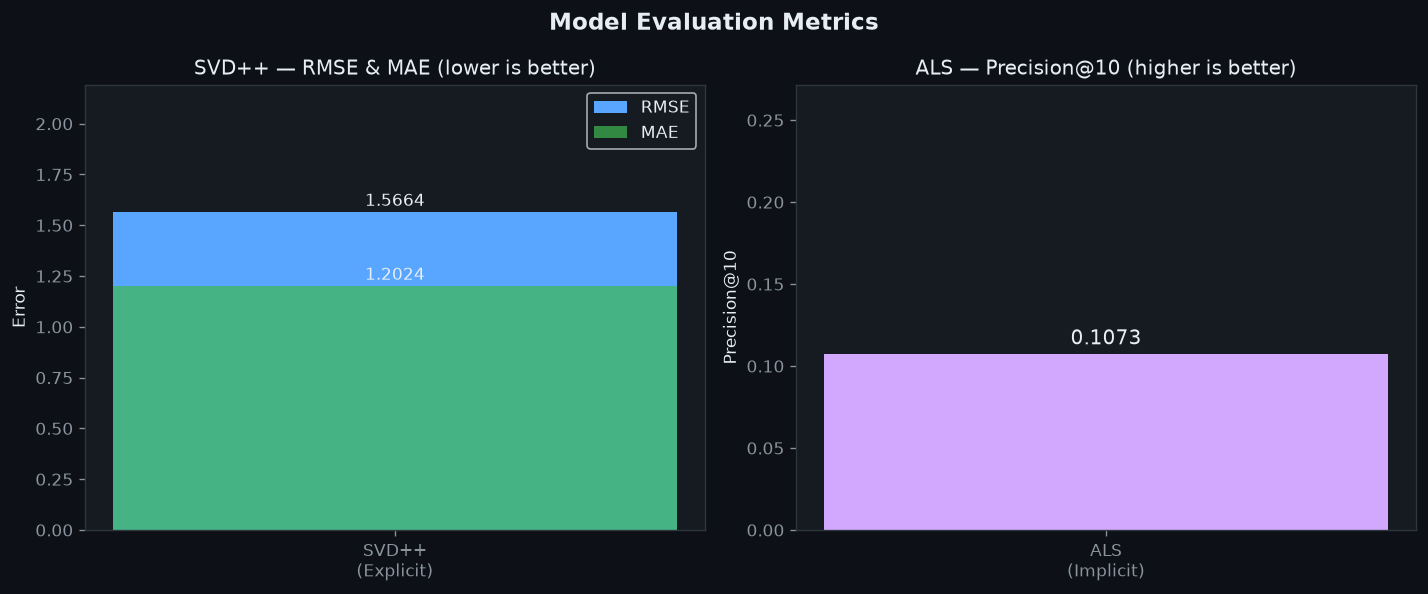

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Evaluation Metrics', fontsize=14, fontweight='bold', color='#e6edf3')

axes[0].bar(['SVD++\n(Explicit)'], [rmse_svd], color=PALETTE[0], width=0.4, label='RMSE')
axes[0].bar(['SVD++\n(Explicit)'], [mae_svd],  color=PALETTE[1], width=0.4, alpha=0.7, label='MAE')
axes[0].set_title('SVD++ — RMSE & MAE (lower is better)', color='#e6edf3')
axes[0].set_ylabel('Error')
axes[0].set_ylim(0, max(rmse_svd, mae_svd) * 1.4)
axes[0].legend()
for bar, val in zip(axes[0].patches, [rmse_svd, mae_svd]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}',
                 ha='center', va='bottom', color='#e6edf3', fontsize=10)

axes[1].bar(['ALS\n(Implicit)'], [precision_k], color=PALETTE[3], width=0.4)
axes[1].set_title('ALS — Precision@10 (higher is better)', color='#e6edf3')
axes[1].set_ylabel('Precision@10')
axes[1].set_ylim(0, min(1.0, precision_k * 1.6 + 0.1))
axes[1].text(0, precision_k + 0.003, f'{precision_k:.4f}', ha='center', va='bottom', color='#e6edf3', fontsize=12)

plt.tight_layout()
plt.show()

## 10. Inference & Recommendation Demo

Now we put the full system to work. We demonstrate three real-world inference scenarios:

| Scenario | Description |
|---|---|
| **A** — Existing User | User has past rating history; hybrid model leverages ALS + SVD++ |
| **B** — Seed-Based | Recommend books similar to a given title (cold-start / book discovery) |
| **C** — Full Hybrid | Known user + seed book together, maximum signal fusion |

---
### Scenario A: Personalized Recommendations for an Existing User

In [88]:
power_users = (
    explicit_df.groupby('UserID')['Rating']
    .agg(['count', 'mean'])
    .query('count >= 15')
    .sort_values('count', ascending=False)
)
demo_user = power_users.index[0]
print(f'Demo User ID       : {demo_user}')
print(f'Number of ratings  : {power_users.loc[demo_user, "count"]}')
print(f'Average rating     : {power_users.loc[demo_user, "mean"]:.2f}')

print("\nUser's top-rated books:")
user_history = (
    explicit_df[explicit_df['UserID'] == demo_user]
    .merge(books_filtered[['ISBN', 'Title', 'Author']], on='ISBN', how='left')
    .sort_values('Rating', ascending=False)
    .head(5)[['Title', 'Author', 'Rating']]
    .reset_index(drop=True)
)
user_history

Demo User ID       : 11676
Number of ratings  : 2870
Average rating     : 7.53

User's top-rated books:


,Title,Author,Rating
0,Der Kleine Prinz,Antoine De Saint-Exupery,10
1,Illuminati.,Dan Brown,10
2,The Poisonwood Bible,Barbara Kingsolver,10
3,Lirael: Daughter Of The Clayr,Garth Nix,10
4,NaN,NaN,10


In [89]:
recs_a = hybrid_recommend(user_id=demo_user, top_n=10)
print(f'Top-10 Hybrid Recommendations for User {demo_user}:')
recs_a

Top-10 Hybrid Recommendations for User 11676:


,ISBN,Title,Author,Year,HybridScore
0,0446600660,Strip Tease,Carl Hiaasen,1994.0,0.7415
1,0670031909,Lost In A Good Book: A Thursday Next Novel,Jasper Fforde,2003.0,0.7009
2,0345303067,2010: Odyssey Two,Arthur C. Clarke,1984.0,0.7006
3,0449215296,Family: The Ties That Bind And Gag,Erma Bombeck,1991.0,0.6651
4,0345272587,The Fellowship Of The Ring,J. R. R. Tolkien,1977.0,0.6096
5,0440235502,October Sky: A Memoir,Homer Hickam,1999.0,0.5903
6,0156012197,The Little Prince,Antoine De Saint-Exupã©Ry,2000.0,0.5689
7,0345423097,Joy School (Ballantine Reader'S Circle),Elizabeth Berg,1998.0,0.5054
8,0671721291,The Ship Who Searched,Anne Mccaffrey,1992.0,0.4978
9,0553582364,A Traitor To Memory,Elizabeth George,2002.0,0.4915


### Scenario B: "More Like This" — Seed Book Recommendations

In [90]:
popular_books = (
    explicit_df.groupby('ISBN')['Rating']
    .agg(['count', 'mean'])
    .query('count >= 50 and mean >= 7')
    .sort_values('count', ascending=False)
)
popular_isbns_with_meta = popular_books[popular_books.index.isin(books_filtered['ISBN'])]
seed_isbn = popular_isbns_with_meta.index[0]
seed_title = books_filtered[books_filtered['ISBN'] == seed_isbn]['Title'].values[0]
seed_author = books_filtered[books_filtered['ISBN'] == seed_isbn]['Author'].values[0]

print(f'Seed Book  : "{seed_title}"')
print(f'Author     : {seed_author}')
print(f'ISBN       : {seed_isbn}')
print(f'Avg Rating : {popular_isbns_with_meta.loc[seed_isbn, "mean"]:.2f} ({popular_isbns_with_meta.loc[seed_isbn, "count"]} ratings)')

Seed Book  : "The Lovely Bones: A Novel"
Author     : Alice Sebold
ISBN       : 0316666343
Avg Rating : 8.30 (348 ratings)


In [91]:
recs_b = hybrid_recommend(user_id=-1, seed_isbn=seed_isbn, top_n=10, w_als=0.0, w_svd=0.0, w_cb=1.0)
print(f'Books similar to "{seed_title}":')
recs_b

Books similar to "The Lovely Bones: A Novel":


,ISBN,Title,Author,Year,HybridScore
0,0316168815,The Lovely Bones,Alice Sebold,2004.0,1.0000
1,3442545528,In Meinem Himmel.,Alice Sebold,2003.0,0.8875
2,0316096199,Lucky : A Memoir,Alice Sebold,2002.0,0.8608
3,0684857820,Lucky,Alice Sebold,1999.0,0.8556
4,0688177867,The Book Borrower: A Novel,Alice Mattison,2000.0,0.4212
5,061810450X,The Wind Done Gone: A Novel,Alice Randall,2001.0,0.2247
6,0684827107,The End Of Alice,A.M. Homes,1997.0,0.1853
7,0837850681,The Story Of Jonah (An Alice In Bibleland Stor...,Alice Joyce Davidson,1984.0,0.1811
8,9129622425,The Other Alice : The Story Of Alice Liddell A...,Cristina Bjork,1993.0,0.1803
9,0345360354,Lovely In Her Bones,Sharyn Mccrumb,1990.0,0.1694


### Scenario C: Full Hybrid — Known User + Seed Book Combined

In [92]:
recs_c = hybrid_recommend(
    user_id=demo_user,
    seed_isbn=seed_isbn,
    top_n=10,
    w_als=0.45,
    w_svd=0.35,
    w_cb=0.20
)
print(f'Full Hybrid Recommendations (User {demo_user} + Seed: "{seed_title}"):')
recs_c

Full Hybrid Recommendations (User 11676 + Seed: "The Lovely Bones: A Novel"):


,ISBN,Title,Author,Year,HybridScore
0,0446600660,Strip Tease,Carl Hiaasen,1994.0,0.6915
1,0670031909,Lost In A Good Book: A Thursday Next Novel,Jasper Fforde,2003.0,0.6579
2,0345303067,2010: Odyssey Two,Arthur C. Clarke,1984.0,0.6548
3,0449215296,Family: The Ties That Bind And Gag,Erma Bombeck,1991.0,0.6254
4,0345272587,The Fellowship Of The Ring,J. R. R. Tolkien,1977.0,0.5766
5,0440235502,October Sky: A Memoir,Homer Hickam,1999.0,0.5630
6,0156012197,The Little Prince,Antoine De Saint-Exupã©Ry,2000.0,0.5449
7,0316168815,The Lovely Bones,Alice Sebold,2004.0,0.5000
8,0345423097,Joy School (Ballantine Reader'S Circle),Elizabeth Berg,1998.0,0.4803
9,0671721291,The Ship Who Searched,Anne Mccaffrey,1992.0,0.4768


## 11. Latent Factor Visualization

We project the ALS **item latent factors** into 2D space using **PCA** to visualize how books cluster in the latent embedding space. Books that are frequently co-rated by similar users should cluster together, revealing semantic neighborhoods.

We color-code points by their average rating to assess whether high-quality books occupy a distinct region of the embedding space.

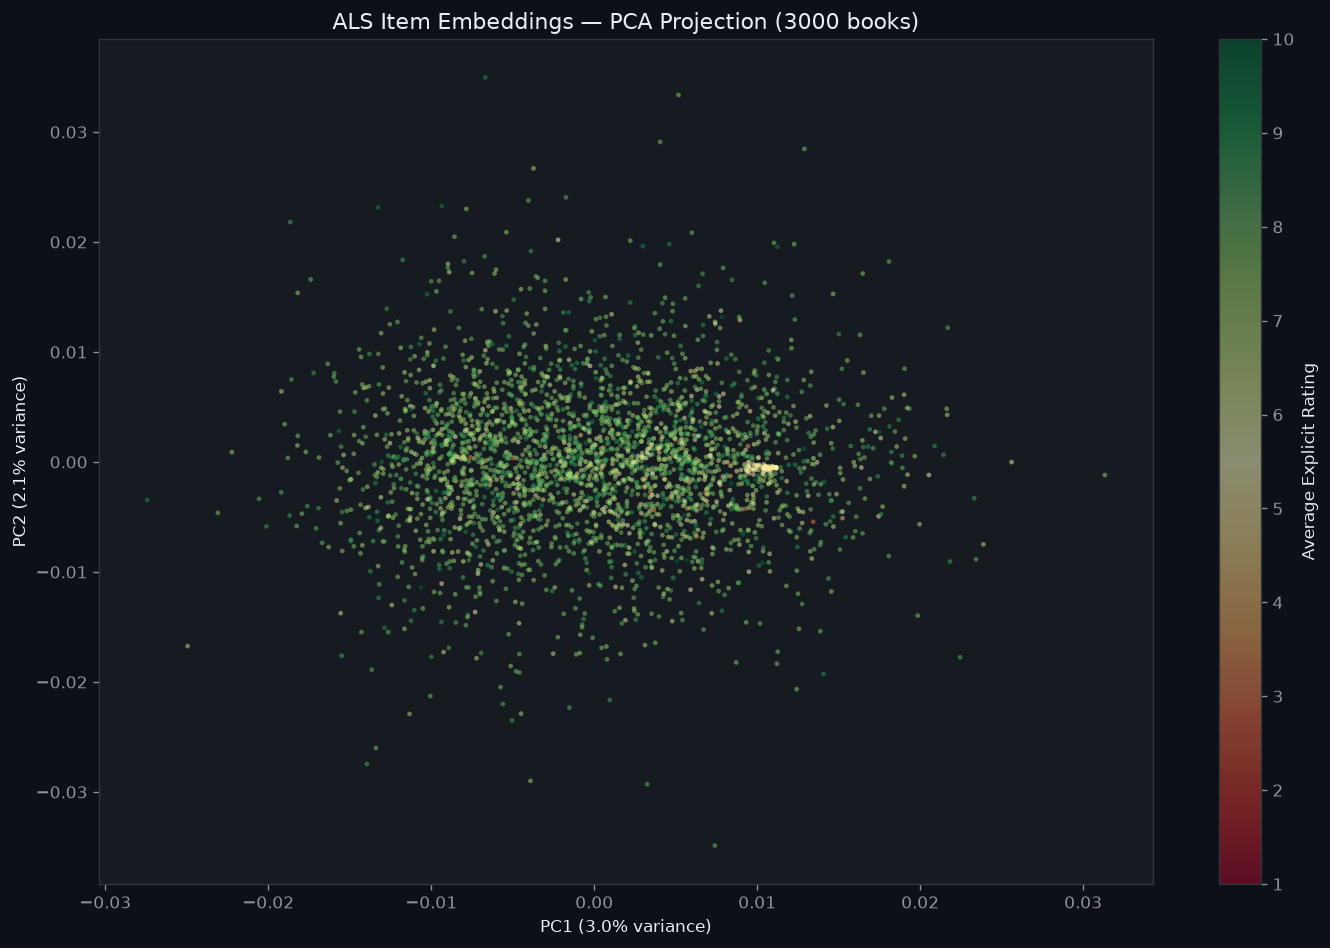

Total explained variance: 5.1%


In [93]:
from sklearn.decomposition import PCA

item_factors = als_model.item_factors

np.random.seed(42)
sample_size = min(3000, len(item_factors))
sample_idx  = np.random.choice(len(item_factors), size=sample_size, replace=False)

pca = PCA(n_components=2, random_state=42)
factors_2d = pca.fit_transform(item_factors[sample_idx])

sampled_isbns = item_enc.inverse_transform(sample_idx)
avg_ratings   = explicit_df.groupby('ISBN')['Rating'].mean().reindex(sampled_isbns).fillna(5)

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(
    factors_2d[:, 0], factors_2d[:, 1],
    c=avg_ratings.values,
    cmap='RdYlGn',
    alpha=0.5,
    s=8,
    linewidths=0
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Average Explicit Rating', color='#e6edf3')
cbar.ax.yaxis.set_tick_params(color='#8b949e')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8b949e')
ax.set_title(f'ALS Item Embeddings — PCA Projection ({sample_size} books)', color='#e6edf3', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.tight_layout()
plt.show()

print(f'Total explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

## 12. Save Models & Artifacts

We serialize all trained models to disk using `pickle` (SVD++, content-based index, encoders), `scipy.sparse` (compressed sparse TF-IDF matrix), and `parquet` (filtered book metadata), enabling fast inference in production without retraining.


In [94]:
import pickle

MODEL_DIR = '../Model/'
os.makedirs(MODEL_DIR, exist_ok=True)

with open(os.path.join(MODEL_DIR, 'svdpp_model.pkl'), 'wb') as f:
    pickle.dump(svdpp, f)

with open(os.path.join(MODEL_DIR, 'als_model.pkl'), 'wb') as f:
    pickle.dump(als_model, f)

with open(os.path.join(MODEL_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf, f)

sp.save_npz(os.path.join(MODEL_DIR, 'tfidf_matrix.npz'), tfidf_matrix)

with open(os.path.join(MODEL_DIR, 'encoders.pkl'), 'wb') as f:
    pickle.dump({'user_enc': user_enc, 'item_enc': item_enc, 'isbn_to_idx': isbn_to_idx}, f)

books_filtered.to_parquet(os.path.join(MODEL_DIR, 'books_filtered.parquet'), index=False)

print('All models and artifacts saved successfully:')
for fname in sorted(os.listdir(MODEL_DIR)):
    fpath = os.path.join(MODEL_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f'  {fname:35s} {size_kb:8.1f} KB')


All models and artifacts saved successfully:
  als_model.pkl                         5139.2 KB
  books_filtered.parquet                 937.4 KB
  encoders.pkl                           436.3 KB
  svdpp_model.pkl                      16930.2 KB
  tfidf_matrix.npz                      1016.6 KB
  tfidf_vectorizer.pkl                   461.6 KB


## 13. Conclusion

### Summary

We built a complete **Hybrid Book Recommendation System** using three complementary approaches:

| Component | Algorithm | Key Metric |
|---|---|---|
| Content-Based | TF-IDF + Cosine Similarity | — |
| Explicit CF | SVD++ (scikit-surprise) | RMSE, MAE |
| Implicit CF | ALS (implicit library) | Precision@10 |
| **Hybrid** | Weighted Score Fusion | Combined |

### Key Findings

- The **Book-Crossing dataset is extremely sparse** (>99.99%), making traditional user-based CF unreliable without activity filtering.
- **Rating=0 (implicit)** constitutes ~62% of all interactions — ignoring these would discard the majority of the signal. ALS is purpose-built for exactly this setting.
- **SVD++** achieves competitive RMSE/MAE on explicit ratings by jointly modeling explicit preferences and implicit item interaction sets.
- The **hybrid ensemble** addresses individual model limitations: content-based handles cold-start, SVD++ provides rating quality signal, and ALS delivers broad personalization coverage.

### Potential Next Steps

- **Deep Learning** — Implement Neural Collaborative Filtering (NCF) or two-tower retrieval models using PyTorch for even richer representations.
- **Side Information** — Incorporate user demographics (age, location) and book metadata (genre, description via NLP) as auxiliary features.
- **Online Learning** — Stream new ratings incrementally to update recommendations in real time.
- **A/B Testing Framework** — Deploy competing recommendation strategies and measure click-through rate and reading completion in production.
- **Diversity & Fairness** — Apply re-ranking techniques (MMR, calibrated recommendations) to avoid filter bubbles and ensure genre diversity.